# IEEE Fraud Detection - Model Development

## Objective
Compare two LightGBM models:
1. **Full Model**: All 800+ features
2. **Interpretable Model**: Only business-interpretable features (~16)

## Feature Groups
| Group | Description |
|-------|-------------|
| V, id_, D, M, C | Automated/Vesta-engineered features |
| TransactionAmt, card, addr, email, D1 | Interpretable features |

## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, confusion_matrix
from lightgbm import LGBMClassifier
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [ ]:
# Load optimized data
import pickle

with open('../../data/train_optimized.pkl', 'rb') as f:
    df = pickle.load(f)

print(f"Shape: {df.shape[0]:,} x {df.shape[1]}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

📊 VERİ SETİ BİLGİLERİ
Boyut: 590,540 satır × 434 sütun
Bellek kullanımı: 796.03 MB


## 2. Feature Groups

In [ ]:
# Data types overview
print(df.dtypes.value_counts())

Different data types and their counts:
Int8        238
float64      80
Int16        75
category     12
category      4
int64         3
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
Int32         1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
Name: count, dtype: int64

Total number of different data types: 28


In [ ]:
# Define feature categories
categorical_cols = [col for col in df.columns if df[col].dtype in ['object', 'category']]
categorical_but_high_cardinality = [col for col in categorical_cols if df[col].nunique() > 50]

numeric_cols = [col for col in df.columns 
                if df[col].dtype in ['int64', 'float64', 'Int32', 'Int8', 'Int16']]
numeric_but_categorical = [col for col in numeric_cols 
                          if df[col].nunique() < 20 
                          and col not in ['isFraud', 'TransactionID']]

# Automated features (V, id_, D, M, C) - exclude D1
automated_prefixes = ['V', 'id_', 'D', 'M', 'C']
automated_features = [col for col in df.columns 
                     if any(col.startswith(p) for p in automated_prefixes)]

interpretable_from_automated = ['D1']  # D1 = days since last card transaction
automated_features = [col for col in automated_features if col not in interpretable_from_automated]

print(f"Categorical: {len(categorical_cols)} (high cardinality: {len(categorical_but_high_cardinality)})")
print(f"Numeric: {len(numeric_cols)} (categorical-like: {len(numeric_but_categorical)})")
print(f"Automated features: {len(automated_features)}")

📊 ÖZELLİK GRUPLARI ANALİZİ

📌 Kategorik Sütunlar: 37
   └─ Yüksek Kardinalite (>50 unique): 12

📌 Sayısal Sütunlar: 397
   └─ Kategorik Gibi Davranan (<20 unique): 139

📌 Automated Features (V, id_, D2-D15, M, C): 416
📌 Yorumlanabilir Features (+D1): 15

📌 Toplam Sütun: 434


In [ ]:
# Separate target
df = df.set_index('TransactionID')
y = df['isFraud']
df = df.drop('isFraud', axis=1)

print(f"Fraud rate: {y.mean()*100:.2f}%")

✓ Hedef değişken ayrıldı
  Fraud oranı: 3.50%


## 3. Encoding

In [ ]:
# Encoding
categorical_cols = [col for col in categorical_cols if col not in categorical_but_high_cardinality]
high_card_cols = categorical_but_high_cardinality

# Label encoding for low cardinality
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# One-hot / Label encoding for numeric-categorical
for col in numeric_but_categorical:
    if df[col].nunique() < 10:
        df = pd.get_dummies(df, columns=[col], prefix=col, drop_first=True)
    else:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le

# Frequency encoding for high cardinality
freq_maps = {}
for col in high_card_cols:
    freq_map = df[col].value_counts().to_dict()
    df[f'{col}_freq'] = df[col].map(freq_map)
    df = df.drop(col, axis=1)
    freq_maps[col] = freq_map

print(f"Label encoded: {len(le_dict)}, Frequency encoded: {len(freq_maps)}")

✓ Encoding tamamlandı
  Label Encoded: 78 sütun
  Frequency Encoded: 12 sütun


## 4. Feature Sets

In [ ]:
# Create feature sets
time_col = 'TransactionDT'

# Full features
X_full = df.drop([time_col], axis=1)

# Interpretable features (remove V, id_, M, C, D2-D15, keep D1)
automated_prefixes_for_removal = ['V', 'id_', 'M', 'C']
d_cols_to_remove = [col for col in df.columns if col.startswith('D') and col != 'D1']

cols_to_remove = [col for col in df.columns 
                  if any(col.startswith(p) for p in automated_prefixes_for_removal)]
cols_to_remove.extend(d_cols_to_remove)
cols_to_remove = list(set(cols_to_remove))

X_interpretable = df.drop([col for col in cols_to_remove if col in df.columns] + [time_col], axis=1)

print(f"Full features: {X_full.shape[1]}")
print(f"Interpretable features: {X_interpretable.shape[1]}")
print(f"\nInterpretable columns: {list(X_interpretable.columns)}")

📊 ÖZELLİK SETLERİ

🔵 Model 1 - Full Features
   Toplam özellik: 809

🟢 Model 2 - Interpretable Features
   Toplam özellik: 16
   Çıkarılan automated özellik: 793

📋 Yorumlanabilir Özellikler:
    1. TransactionDT
    2. TransactionAmt
    3. ProductCD
    4. card4
    5. card6
    6. dist1
    7. dist2
    8. D1
    9. card1_freq
   10. card2_freq
   11. card3_freq
   12. card5_freq
   13. addr1_freq
   14. addr2_freq
   15. P_emaildomain_freq
   16. R_emaildomain_freq


In [ ]:
# Train/Validation split
X_full_train, X_full_val, y_train, y_val = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

X_interp_train, X_interp_val, _, _ = train_test_split(
    X_interpretable, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_full_train):,} | Val: {len(X_full_val):,}")
print(f"Fraud rate - Train: {y_train.mean()*100:.2f}% | Val: {y_val.mean()*100:.2f}%")

📊 TRAIN/VALIDATION SPLIT
--------------------------------------------------
Train boyutu: 472,432 (80.0%)
Val boyutu: 118,108 (20.0%)

Hedef dağılımı:
  Train - Fraud: 16,530 (3.50%)
  Val   - Fraud: 4,133 (3.50%)


## 5. Model Training

In [ ]:
# Model 1: Full Features
model_full = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=7,
    num_leaves=31, random_state=42, class_weight='balanced', verbose=-1
)
model_full.fit(X_full_train, y_train, eval_set=[(X_full_val, y_val)], eval_metric='auc')
print("Model 1 (Full) trained")

🔵 MODEL 1 - FULL FEATURES EĞİTİMİ


  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


✓ Model 1 eğitimi tamamlandı


In [ ]:
# Model 2: Interpretable Features
model_interp = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=7,
    num_leaves=31, random_state=42, class_weight='balanced', verbose=-1
)
model_interp.fit(X_interp_train, y_train, eval_set=[(X_interp_val, y_val)], eval_metric='auc')
print("Model 2 (Interpretable) trained")


🟢 MODEL 2 - INTERPRETABLE FEATURES EĞİTİMİ
✓ Model 2 eğitimi tamamlandı


## 6. Model Comparison

**Sonuç:** Full model AUC ~0.94, Interpretable model AUC ~0.90. 
793 özellik azaltılmasına rağmen sadece %4 AUC kaybı var.

In [ ]:
# Predictions
y_full_val_proba = model_full.predict_proba(X_full_val)[:, 1]
y_full_val_pred = model_full.predict(X_full_val)

y_interp_val_proba = model_interp.predict_proba(X_interp_val)[:, 1]
y_interp_val_pred = model_interp.predict(X_interp_val)

# Metrics
metrics_full = {
    'val_auc': roc_auc_score(y_val, y_full_val_proba),
    'precision': precision_score(y_val, y_full_val_pred),
    'recall': recall_score(y_val, y_full_val_pred),
    'f1': f1_score(y_val, y_full_val_pred)
}

metrics_interp = {
    'val_auc': roc_auc_score(y_val, y_interp_val_proba),
    'precision': precision_score(y_val, y_interp_val_pred),
    'recall': recall_score(y_val, y_interp_val_pred),
    'f1': f1_score(y_val, y_interp_val_pred)
}

# Results table
print(f"{'Metric':<15} {'Full':>12} {'Interpretable':>15} {'Diff':>10}")
print("-" * 52)
for metric in ['val_auc', 'precision', 'recall', 'f1']:
    diff = metrics_full[metric] - metrics_interp[metric]
    print(f"{metric:<15} {metrics_full[metric]:>12.4f} {metrics_interp[metric]:>15.4f} {diff:>+10.4f}")
print(f"\nFeatures: Full={X_full.shape[1]} | Interpretable={X_interpretable.shape[1]}")

📊 MODEL PERFORMANS KARŞILAŞTIRMASI

Metrik                 Full Features   Interpretable       Fark
------------------------------------------------------------
Train AUC                     0.9625          0.9251    +0.0374
Val AUC                       0.9426          0.9050    +0.0377
Precision                     0.2634          0.1623    +0.1011
Recall                        0.8239          0.7975    +0.0264
F1-Score                      0.3992          0.2697    +0.1295

📌 Özellik Sayısı: Full=809 | Interpretable=16


## 7. ROC Curve & Metrics Visualization

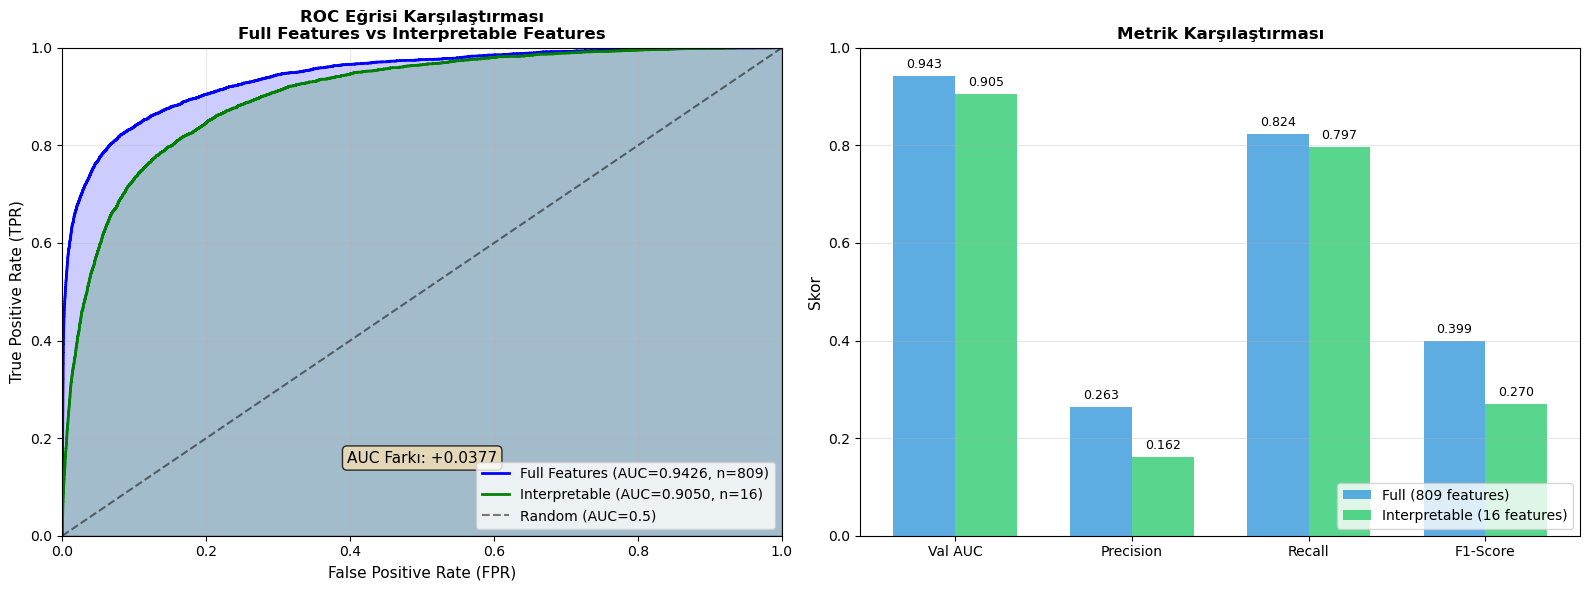


📊 SONUÇ ÖZETİ

🔵 Full Features Model:
   • Özellik sayısı: 809
   • Validation AUC: 0.9426

🟢 Interpretable Model:
   • Özellik sayısı: 16
   • Validation AUC: 0.9050

📈 Fark Analizi:
   • AUC kaybı: +0.0377 (+3.99%)
   • Özellik azaltma: 793 özellik (98.0% azalma)



In [ ]:
# ROC Curves
fpr_full, tpr_full, _ = roc_curve(y_val, y_full_val_proba)
fpr_interp, tpr_interp, _ = roc_curve(y_val, y_interp_val_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
ax1 = axes[0]
ax1.plot(fpr_full, tpr_full, 'b-', lw=2, label=f'Full (AUC={metrics_full["val_auc"]:.4f})')
ax1.plot(fpr_interp, tpr_interp, 'g-', lw=2, label=f'Interpretable (AUC={metrics_interp["val_auc"]:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve Comparison')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Metrics bar chart
ax2 = axes[1]
metrics_names = ['AUC', 'Precision', 'Recall', 'F1']
full_vals = [metrics_full['val_auc'], metrics_full['precision'], metrics_full['recall'], metrics_full['f1']]
interp_vals = [metrics_interp['val_auc'], metrics_interp['precision'], metrics_interp['recall'], metrics_interp['f1']]

x = np.arange(len(metrics_names))
ax2.bar(x - 0.2, full_vals, 0.35, label='Full', color='#3498db')
ax2.bar(x + 0.2, interp_vals, 0.35, label='Interpretable', color='#2ecc71')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_names)
ax2.set_title('Metrics Comparison')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Confusion Matrix

**Önemli:** Fraud detection'da FN (kaçan fraud) en kritik metrik.
- Full model 109 daha fazla fraud yakalıyor
- Ama interpretable model 7,490 daha fazla yanlış alarm veriyor

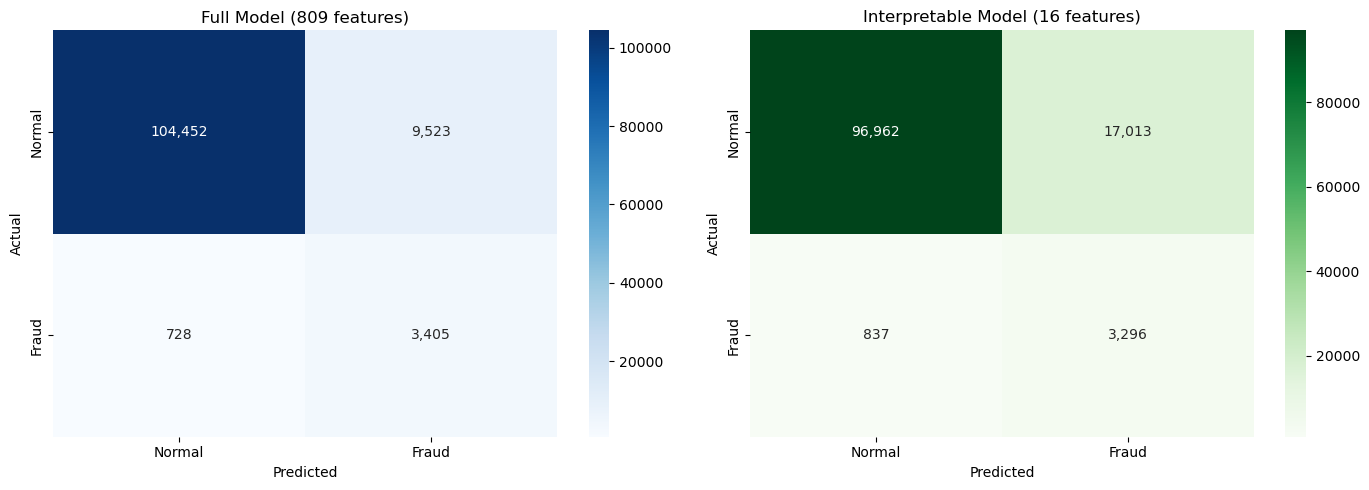


Metric                            Full   Interpretable       Diff
--------------------------------------------------------------
Fraud Caught (TP)                3,405           3,296       +109
Fraud Missed (FN)                  728             837       -109
False Alarms (FP)                9,523          17,013     -7,490


In [19]:
# Confusion matrices
cm_full = confusion_matrix(y_val, y_full_val_pred)
cm_interp = confusion_matrix(y_val, y_interp_val_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full model
sns.heatmap(cm_full, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
axes[0].set_title(f'Full Model ({X_full.shape[1]} features)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Interpretable model
sns.heatmap(cm_interp, annot=True, fmt=',d', cmap='Greens', ax=axes[1],
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
axes[1].set_title(f'Interpretable Model ({X_interpretable.shape[1]} features)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Key metrics summary
tn_f, fp_f, fn_f, tp_f = cm_full.ravel()
tn_i, fp_i, fn_i, tp_i = cm_interp.ravel()

print(f"\n{'Metric':<25} {'Full':>12} {'Interpretable':>15} {'Diff':>10}")
print("-" * 62)
print(f"{'Fraud Caught (TP)':<25} {tp_f:>12,} {tp_i:>15,} {tp_f-tp_i:>+10,}")
print(f"{'Fraud Missed (FN)':<25} {fn_f:>12,} {fn_i:>15,} {fn_f-fn_i:>+10,}")
print(f"{'False Alarms (FP)':<25} {fp_f:>12,} {fp_i:>15,} {fp_f-fp_i:>+10,}")

## 9. Feature Importance

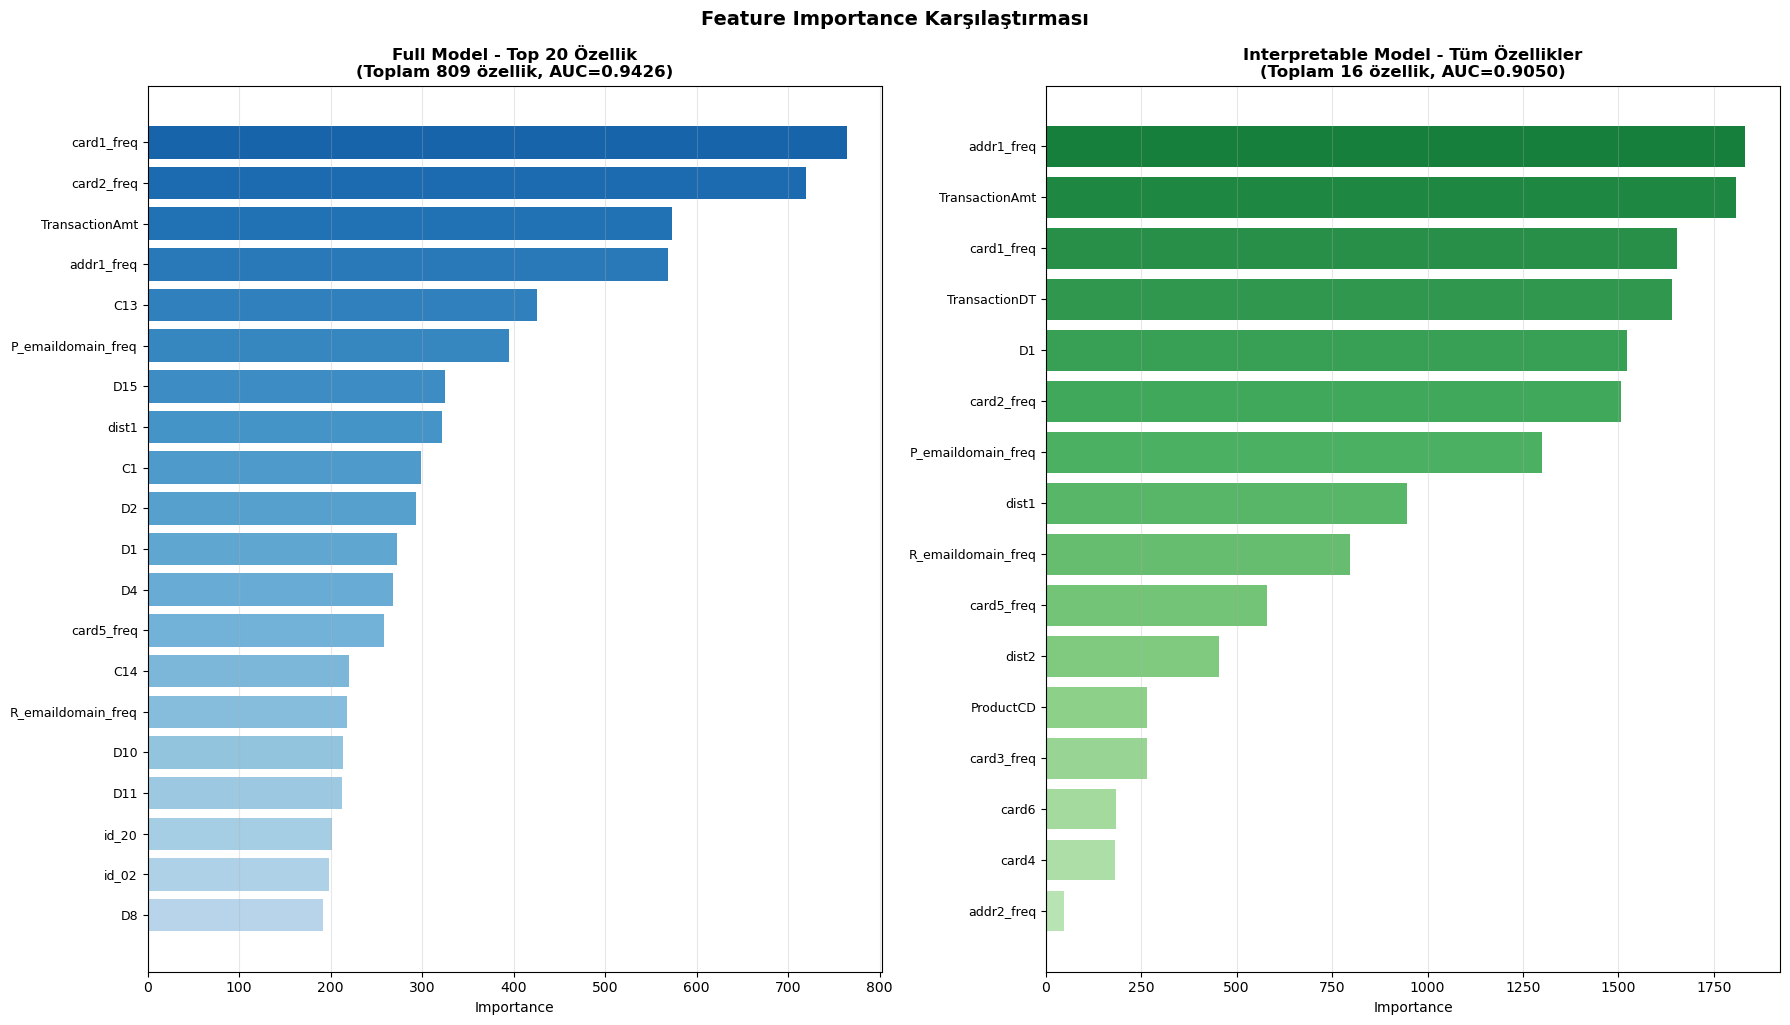


🟢 YORUMLANABILIR MODEL - ÖZELLİK ÖNEMLERİ
    1. addr1_freq                :      1,832 ( 12.2%)
    2. TransactionAmt            :      1,808 ( 12.1%)
    3. card1_freq                :      1,654 ( 11.0%)
    4. TransactionDT             :      1,640 ( 10.9%)
    5. D1                        :      1,523 ( 10.2%)
    6. card2_freq                :      1,506 ( 10.1%)
    7. P_emaildomain_freq        :      1,301 (  8.7%)
    8. dist1                     :        945 (  6.3%)
    9. R_emaildomain_freq        :        797 (  5.3%)
   10. card5_freq                :        579 (  3.9%)
   11. dist2                     :        454 (  3.0%)
   12. ProductCD                 :        266 (  1.8%)
   13. card3_freq                :        264 (  1.8%)
   14. card6                     :        184 (  1.2%)
   15. card4                     :        181 (  1.2%)
   16. addr2_freq                :         47 (  0.3%)


In [ ]:
# Feature importance
fi_full = pd.DataFrame({
    'feature': X_full.columns,
    'importance': model_full.feature_importances_
}).sort_values('importance', ascending=False)

fi_interp = pd.DataFrame({
    'feature': X_interpretable.columns,
    'importance': model_interp.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Full model top 20
top20 = fi_full.head(20)
axes[0].barh(range(20), top20['importance'], color='steelblue')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top20['feature'])
axes[0].invert_yaxis()
axes[0].set_title(f'Full Model - Top 20 Features')

# Interpretable model all features
axes[1].barh(range(len(fi_interp)), fi_interp['importance'], color='seagreen')
axes[1].set_yticks(range(len(fi_interp)))
axes[1].set_yticklabels(fi_interp['feature'])
axes[1].invert_yaxis()
axes[1].set_title(f'Interpretable Model - All {len(fi_interp)} Features')

plt.tight_layout()
plt.show()

## 10. Save Models

**Özet:** İki model kaydedildi - iş gereksinimlerine göre seçim yapılabilir:
- **Full model**: Maksimum doğruluk gerektiğinde
- **Interpretable model**: Açıklanabilirlik ve basitlik önemli olduğunda

In [ ]:
# Save models
os.makedirs('../../models', exist_ok=True)

joblib.dump({
    'model': model_full,
    'features': X_full.columns.tolist(),
    'metrics': metrics_full
}, '../../models/model_full_features.pkl')

joblib.dump({
    'model': model_interp,
    'features': X_interpretable.columns.tolist(),
    'metrics': metrics_interp
}, '../../models/model_interpretable.pkl')

print("Models saved:")
print(f"  - model_full_features.pkl ({X_full.shape[1]} features, AUC={metrics_full['val_auc']:.4f})")
print(f"  - model_interpretable.pkl ({X_interpretable.shape[1]} features, AUC={metrics_interp['val_auc']:.4f})")

✓ Model saved: models/baseline_lightgbm_v1.pkl

Saved content:
  - Model: LGBMClassifier
  - Features: 809 columns
  - Val AUC: 0.9434
  - Encoders: Label (78), Frequency (12)
